In [1]:
from google.colab import files
uploaded = files.upload()

Saving iris (1).data to iris (1).data


In [2]:
import pandas as pd
columns = ['sepal-length','sepal-width','petal-length','petal-width','class']
iris = pd.read_csv('iris.data',names=columns)
iris.head()

,sepal-length,sepal-width,petal-length,petal-width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
X = iris[['sepal-length','sepal-width','petal-length','petal-width']]
X = X.values
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [4]:
y = iris[['class']]
y = y.values.ravel()
y

array(['Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-versic

In [5]:
#X = (X - X.min(axis=0))/(X.max(axis=0) - X.min(axis=0))
#X

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn.metrics as metrics
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [11]:
depth = 15
n = 50

k = []
k_training_acc = []
k_testing_acc = []

for i in range(1,depth+1):

  training_acc = np.zeros(n)
  testing_acc = np.zeros(n)
  k.append(i)

  for j in range(n):
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=j)
    dt_classifier = DecisionTreeClassifier(max_depth=i, criterion='entropy')
    dt_classifier.fit(X_train, y_train)

    y_train_hat = dt_classifier.predict(X_train)
    y_test_hat = dt_classifier.predict(X_test)

    training_acc[j] = metrics.accuracy_score(y_train, y_train_hat)
    testing_acc[j] = metrics.accuracy_score(y_test, y_test_hat)

  k_training_acc.append(training_acc.mean())
  k_testing_acc.append(testing_acc.mean())

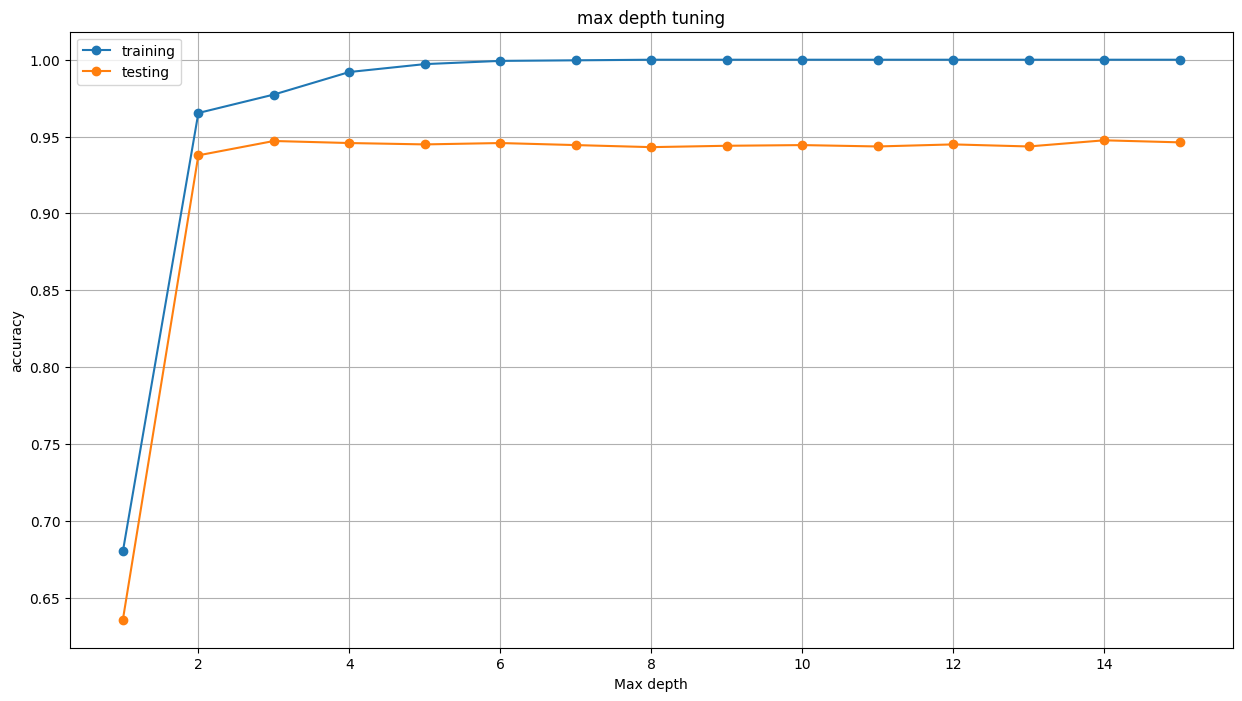

In [12]:
plt.figure(figsize=(15,8))
plt.plot(k,k_training_acc, '-o', label='training')
plt.plot(k,k_testing_acc,'-o', label='testing')
plt.legend()
plt.xlabel('Max depth')
plt.ylabel('accuracy')
plt.grid()
plt.title('max depth tuning')
plt.show()

[Text(0.375, 0.875, 'x[2] <= 2.45\nentropy = 1.585\nsamples = 150\nvalue = [50, 50, 50]'),
 Text(0.25, 0.625, 'entropy = 0.0\nsamples = 50\nvalue = [50, 0, 0]'),
 Text(0.3125, 0.75, 'True  '),
 Text(0.5, 0.625, 'x[3] <= 1.75\nentropy = 1.0\nsamples = 100\nvalue = [0, 50, 50]'),
 Text(0.4375, 0.75, '  False'),
 Text(0.25, 0.375, 'x[2] <= 4.95\nentropy = 0.445\nsamples = 54\nvalue = [0, 49, 5]'),
 Text(0.125, 0.125, 'entropy = 0.146\nsamples = 48\nvalue = [0, 47, 1]'),
 Text(0.375, 0.125, 'entropy = 0.918\nsamples = 6\nvalue = [0, 2, 4]'),
 Text(0.75, 0.375, 'x[2] <= 4.85\nentropy = 0.151\nsamples = 46\nvalue = [0, 1, 45]'),
 Text(0.625, 0.125, 'entropy = 0.918\nsamples = 3\nvalue = [0, 1, 2]'),
 Text(0.875, 0.125, 'entropy = 0.0\nsamples = 43\nvalue = [0, 0, 43]')]

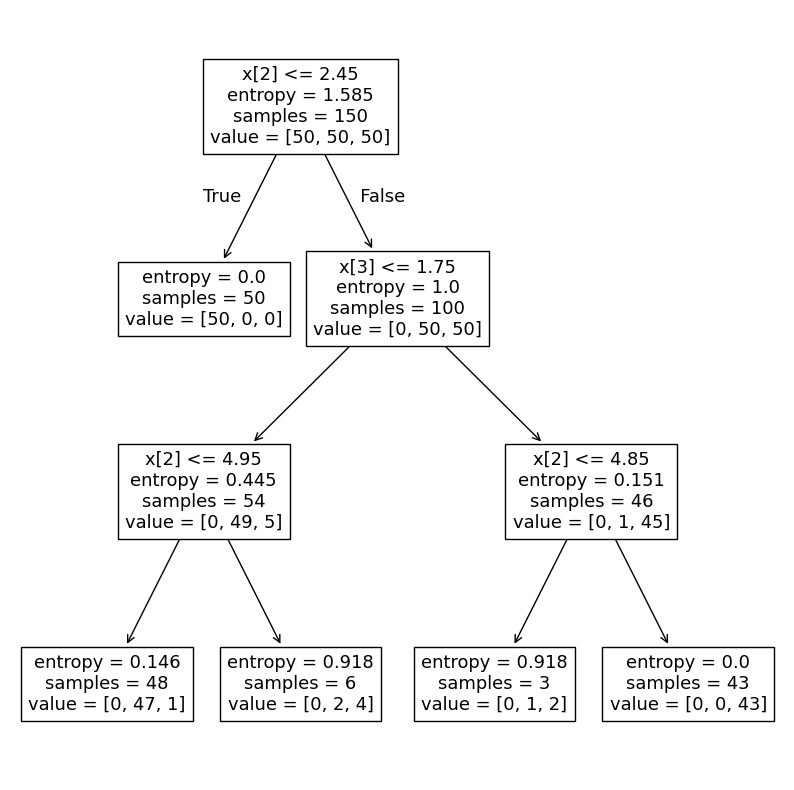

In [17]:
from sklearn import tree
dt_classifier = DecisionTreeClassifier(max_depth=3, criterion='entropy')
dt_classifier.fit(X, y)

plt.figure(figsize=(10,10))
tree.plot_tree(dt_classifier)

In [18]:

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=32)
dt_classifier = DecisionTreeClassifier(max_depth=3, criterion='entropy')
dt_classifier.fit(X_train, y_train)

y_train_hat = dt_classifier.predict(X_train)
y_test_hat = dt_classifier.predict(X_test)

print(metrics.accuracy_score(y_test,y_test_hat))
print(metrics.confusion_matrix(y_test,y_test_hat))
print(metrics.classification_report(y_test, y_test_hat))


0.9666666666666667
[[12  0  0]
 [ 0  9  0]
 [ 0  1  8]]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        12
Iris-versicolor       0.90      1.00      0.95         9
 Iris-virginica       1.00      0.89      0.94         9

       accuracy                           0.97        30
      macro avg       0.97      0.96      0.96        30
   weighted avg       0.97      0.97      0.97        30

